# Masked operators — missing data on a structured grid

Real geophysical datasets are *partial*. Clouds occlude satellite retrievals; ARGO floats sample a sparse subset of the ocean; tide gauges miss days; ice cores have hiatuses; GPS stations drop out. The **kernel covariance over the full regular grid** is structured (Toeplitz, Kronecker, block-tridiagonal); the **kernel over the observed subset** is structureless dense. Materializing the subset throws away every dollar of structure you spent the last five notebooks earning back.

`MaskedOperator` is the bridge: keep the structured base operator on the full grid, attach boolean row/column masks, and perform every matvec at the *base* operator's cost — without ever assembling the dense subset matrix. This is the single most useful operator for working with real environmental data.

## 0. Where masked operators show up in geoscience

The list of geoscience workflows that need *exactly* this primitive:

- **The simplest case — subset of a plain MVN**: a generic dense covariance $\Sigma\in\mathbb{R}^{N\times N}$ describing some multivariate normal field, and you want the marginal over an observed subset. `MaskedOperator(MatrixLinearOperator(Σ), mask, mask)` returns $\Sigma[r][:,r]$ as an operator without copying — useful for parameter tying across many masks (cross-validation folds, leave-one-out diagnostics, multiple cloud frames against the same prior).
- **Markovian GPs with missing observations**: Matérn-1/2, -3/2, -5/2 GPs in time as state-space models have a `BlockTriDiag` precision on a regular grid. Real geophysical timeseries — GPS, tide gauges, soil-moisture probes, eddy-covariance flux towers — drop observations regularly. `MaskedOperator(BlockTriDiag, time_mask, time_mask)` keeps the $O(N d^3)$ banded prior on the full timeline and selects observed timesteps cheaply. This is the standard pattern for state-space GP regression with gaps.
- **Cloud-masked satellite retrievals**: SST (MODIS, AVHRR, VIIRS), ocean colour / chlorophyll, atmospheric CO$_2$ (OCO-2, GOSAT), surface temperature. The covariance on the underlying lat × lon grid is `Kronecker(K_lat, K_lon)`; the cloud mask flags valid pixels. `MaskedOperator(Kronecker(...), cloud_mask, cloud_mask)` keeps the $O(N\log\sqrt N)$ matvec.
- **ARGO float profiles on depth × lat × lon**: floats sample a small fraction of the global ocean; the full-grid covariance is a `Kronecker` of three structured factors, masking flags observed casts.
- **Irregular tide-gauge / mooring time series**: the "regular grid + missing" framing — the underlying time grid is regular (hourly / daily), and the mask flags reporting timesteps. Treats irregularly-sampled but locally-discrete data as masked Toeplitz / BlockTriDiag.
- **Dropped GPS station epochs**: continuous GPS networks have outages from power, ice, vandalism. Time series at each station are masked; cross-station covariances need masked block structure.
- **Ice-core hiatuses**: depth–age series with missing intervals; Toeplitz on the full age grid + temporal mask.
- **InSAR / seismic data with masked pixels** from layover, shadowing, decorrelation, or low-coherence regions.
- **Spacetime data assimilation with missing observations**: an EnKF / 4D-Var system has a structured prior covariance; observation operators apply masks (and interpolation) to compare against partial measurements.
- **Cross-covariance for prediction at unobserved grid points**: train rows = observed indices, test cols = prediction indices. *Asymmetric* masking — `MaskedOperator(K, row_mask=train, col_mask=test)` produces $K_{*X}$ without forming the full dense cross-cov.

The mental shortcut: **whenever the data lives on (or near) a regular grid but only a subset is observed, `MaskedOperator` lets the structured base do the work**.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    BlockTriDiag,
    Kronecker,
    MaskedOperator,
    Toeplitz,
    cholesky,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

## 1. The setup — base operator + boolean masks

Given a structured square base $A\in\mathbb{R}^{N\times N}$ and boolean masks $r,c\in\{0,1\}^N$ that pick out the observed rows and columns, the masked operator is the sub-matrix:

```{math}
:label: eq:masked-def
\tilde A \;=\; A[r][:,c] \;\in\; \mathbb{R}^{(\sum r)\times(\sum c)}
```

Two cases worth distinguishing:

- **Symmetric masking** ($r = c$): $\tilde A$ is square, symmetric (if $A$ is), PSD (if $A$ is). The standard "sub-covariance over observed indices" pattern.
- **Asymmetric masking** ($r \neq c$): $\tilde A$ is rectangular. The standard "cross-covariance" pattern — train rows by test columns, observed by predicted, etc.

The constructor signature is `MaskedOperator(base, row_mask, col_mask)`. Tags don't auto-propagate (PSD on $A$ doesn't imply PSD on $\tilde A$ unless $r = c$), so you tag explicitly when you know.

## 2. The matvec trick — scatter, base matvec, gather

The headline. Apply the base matvec to a *zero-padded* full-length vector and extract the masked rows:

```{math}
:label: eq:masked-mv
\tilde A v \;=\; \big(A \cdot \mathrm{scatter}_c(v)\big)[r]
```

where $\mathrm{scatter}_c(v) \in \mathbb{R}^N$ has $v$ at the column-mask positions and zero elsewhere. Cost = base matvec cost. *No materialization, no loss of structure*.

The intuition: the columns we don't read can be set to anything; the rows we don't observe we throw away. So pad with zeros, run the structured base matvec on the full grid, then gather the rows of interest.

In [2]:
# Stationary RBF on a regular 1-D grid → Toeplitz base
n = 24
grid = jnp.linspace(0, 4, n)
ell = 0.5
col_kernel = jnp.exp(-0.5 * (grid - grid[0])**2 / ell**2)
T = Toeplitz(col_kernel, tags=lx.positive_semidefinite_tag)

# 30% missing observations (random)
key = jax.random.PRNGKey(1)
mask = jax.random.bernoulli(key, p=0.7, shape=(n,))
print(f"observed: {int(mask.sum())} of {n}  ({100*float(mask.mean()):.0f}%)")

# Symmetric-masked Toeplitz
M_op = MaskedOperator(T, mask, mask, tags=lx.positive_semidefinite_tag)
M_dense = T.as_matrix()[np.where(mask)[0]][:, np.where(mask)[0]]

v = jax.random.normal(jax.random.PRNGKey(2), (int(mask.sum()),))
err = jnp.linalg.norm(M_op.mv(v) - M_dense @ v)
print(f"shape         : {M_op.out_size()} x {M_op.in_size()}")
print(f"matvec error  : {err:.2e}")
print(f"PSD propagated: {lx.is_positive_semidefinite(M_op)}")

observed: 17 of 24  (71%)


shape         : 17 x 17
matvec error  : 2.91e-15
PSD propagated: True


## 3. The simplest case — plain MVN base

Before reaching for any structure, the most basic use of `MaskedOperator` is the *subset of a multivariate normal*. Take any dense covariance $\Sigma\in\mathbb{R}^{N\times N}$ representing an MVN over the full grid, attach a mask, and you get the marginal sub-covariance over the observed indices — *as an operator, without copying*.

```{math}
:label: eq:masked-mvn
\Sigma_{\mathrm{obs}} \;=\; \Sigma[r][:,r], \qquad x_{\mathrm{obs}} \sim \mathcal{N}(0, \Sigma_{\mathrm{obs}})
```

Mathematically this is just the Gaussian marginal property — the marginal of an MVN over a subset of indices is itself an MVN with the obvious sub-covariance. Computationally the win is when you have *one stored $\Sigma$* and need to apply *many different masks* (cross-validation folds, leave-one-out diagnostics, comparing several frames of cloud cover against the same prior). The base `MatrixLinearOperator` stays in place; only the masks change.

In [3]:
# Build a generic dense MVN covariance — no special structure, just a random PSD matrix
n_mvn = 12
key = jax.random.PRNGKey(40)
A = jax.random.normal(key, (n_mvn, n_mvn))
Sigma = A @ A.T + 0.1 * jnp.eye(n_mvn)
Sigma_op = lx.MatrixLinearOperator(Sigma, lx.positive_semidefinite_tag)

# Same base, several masks — no recomputation of Σ
masks = [
    jnp.array([True, True, True, True, True, True, True, True, False, False, False, False]),
    jnp.array([True, False, True, False, True, False, True, False, True, False, True, False]),
    jnp.array([True]*4 + [False]*4 + [True]*4),
]
for i, m in enumerate(masks):
    M = MaskedOperator(Sigma_op, m, m, tags=lx.positive_semidefinite_tag)
    ref = Sigma[np.where(m)[0]][:, np.where(m)[0]]
    v = jax.random.normal(jax.random.PRNGKey(50+i), (M.in_size(),))
    err = jnp.linalg.norm(M.mv(v) - ref @ v)
    print(f"mask {i}: {int(m.sum())}/{n_mvn} observed   matvec error = {err:.2e}   PSD = {lx.is_positive_semidefinite(M)}")

mask 0: 8/12 observed   matvec error = 0.00e+00   PSD = True


mask 1: 6/12 observed   matvec error = 5.26e-15   PSD = True
mask 2: 8/12 observed   matvec error = 0.00e+00   PSD = True


## 4. The 2-D case — `MaskedOperator(Kronecker(K_x, K_y), ...)`

This is the canonical "satellite retrieval with cloud cover" pattern. The full $n_x\times n_y$ grid carries a `Kronecker(Toeplitz_x, Toeplitz_y)` covariance — $O(N\log\sqrt N)$ matvec. The cloud mask flags valid pixels (a 2-D boolean field, flattened into an $N$-vector). The masked operator keeps the Kronecker matvec, masking only on the input/output.

In [4]:
nx, ny = 24, 18
gx = jnp.linspace(0, 3, nx)
gy = jnp.linspace(0, 2, ny)
ell_x, ell_y = 0.4, 0.3
cx = jnp.exp(-0.5 * (gx - gx[0])**2 / ell_x**2)
cy = jnp.exp(-0.5 * (gy - gy[0])**2 / ell_y**2)

T_x = Toeplitz(cx, tags=lx.positive_semidefinite_tag)
T_y = Toeplitz(cy, tags=lx.positive_semidefinite_tag)
K_2d = Kronecker(T_x, T_y)
N = nx * ny

# Simulate a cloud mask: a smooth random field thresholded
key = jax.random.PRNGKey(11)
cloud_field = jax.random.normal(key, (nx, ny))
cloud_field = jnp.cumsum(cloud_field, axis=0) + jnp.cumsum(cloud_field, axis=1)
cloud_mask = (cloud_field > jnp.median(cloud_field) - 0.3).flatten()
print(f"valid pixels : {int(cloud_mask.sum())} / {N}  ({100*float(cloud_mask.mean()):.0f}%)")

# Masked Kronecker — full-grid Kron matvec under the hood
M_2d = MaskedOperator(K_2d, cloud_mask, cloud_mask, tags=lx.positive_semidefinite_tag)
v = jax.random.normal(jax.random.PRNGKey(12), (M_2d.in_size(),))

K_dense = jnp.kron(T_x.as_matrix(), T_y.as_matrix())
ref = K_dense[np.where(cloud_mask)[0]][:, np.where(cloud_mask)[0]] @ v
err = jnp.linalg.norm(M_2d.mv(v) - ref)
print(f"masked-Kron matvec error : {err:.2e}")
print(f"masked shape             : {M_2d.in_size()} x {M_2d.out_size()}")

valid pixels : 223 / 432  (52%)


masked-Kron matvec error : 2.28e-14
masked shape             : 223 x 223


## 5. A realistic-flavour figure — cloud-masked SST sample

Draw a 2-D stationary GP on the $24\times 18$ grid, then apply the cloud mask. Left: the underlying field (what the GP "knows"). Right: the masked observations (what the satellite delivers). The covariance machinery in the rest of `gaussx` works against the *masked operator* without ever forming the dense $M\times M$ submatrix.

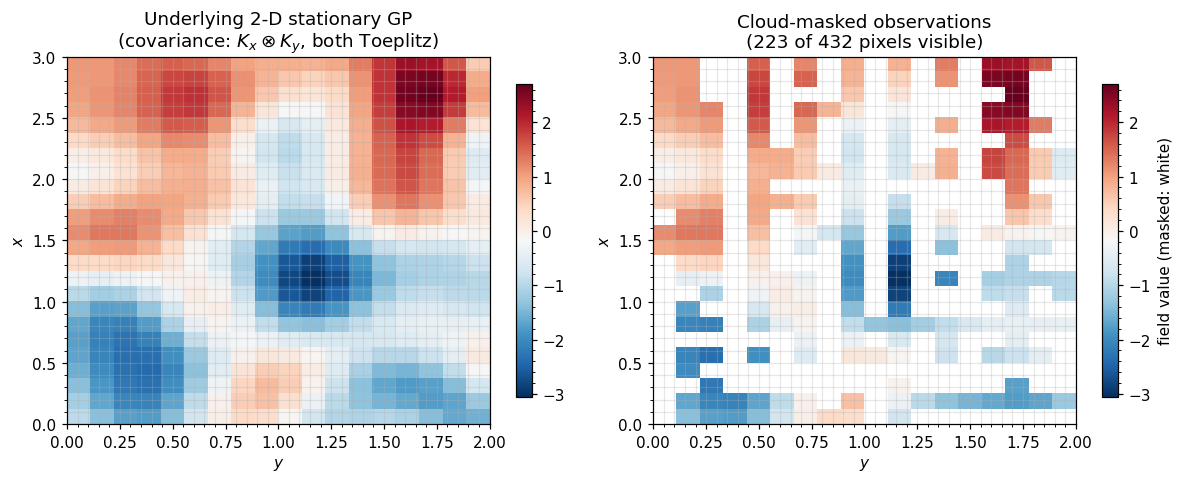

In [5]:
# Sample from the 2-D stationary GP via factor eigendecompositions
la, Qx = jnp.linalg.eigh(T_x.as_matrix())
mu, Qy = jnp.linalg.eigh(T_y.as_matrix())
eigs_2d = la[:, None] * mu[None, :]
z = jax.random.normal(jax.random.PRNGKey(20), (nx, ny))
field = Qx @ (jnp.sqrt(jnp.clip(eigs_2d, 0)) * (Qx.T @ z @ Qy)) @ Qy.T
masked_field = jnp.where(cloud_mask.reshape(nx, ny), field, jnp.nan)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
vmin, vmax = float(field.min()), float(field.max())
im0 = axes[0].imshow(field, cmap="RdBu_r", vmin=vmin, vmax=vmax,
                     extent=[gy[0], gy[-1], gx[0], gx[-1]], origin="lower", aspect="auto")
axes[0].set_title("Underlying 2-D stationary GP\n(covariance: $K_x \\otimes K_y$, both Toeplitz)")
axes[0].set_xlabel("$y$"); axes[0].set_ylabel("$x$")
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(masked_field, cmap="RdBu_r", vmin=vmin, vmax=vmax,
                     extent=[gy[0], gy[-1], gx[0], gx[-1]], origin="lower", aspect="auto")
axes[1].set_title(f"Cloud-masked observations\n({int(cloud_mask.sum())} of {N} pixels visible)")
axes[1].set_xlabel("$y$"); axes[1].set_ylabel("$x$")
plt.colorbar(im1, ax=axes[1], shrink=0.85, label="field value (masked: white)")
plt.tight_layout()
plt.show()

## 6. Markovian GPs — `MaskedOperator(BlockTriDiag, ...)`

State-space GPs (Matérn-1/2, -3/2, -5/2 in time; AR(p) priors; OU processes) have a `BlockTriDiag` precision on a regular time grid, with $O(Nd^3)$ Cholesky / solve / sampling. Real environmental timeseries arrive with gaps — GPS outages, sensor downtime, missed satellite passes, daily-vs-hourly scheduling. Masking lets us keep the cheap banded prior over the *full* timeline and select observed timesteps without ever forming a dense subset.

The pattern: build the state-space prior once on the regular grid, then `MaskedOperator(prior, observation_mask, observation_mask)` to obtain the prior covariance over observed timesteps for likelihood evaluation, conditional posterior, RTS smoothing, etc.

full grid    : 64 timesteps
observed     : 39 timesteps  (61%)
masked shape : 39 x 39


matvec error : 1.67e-16


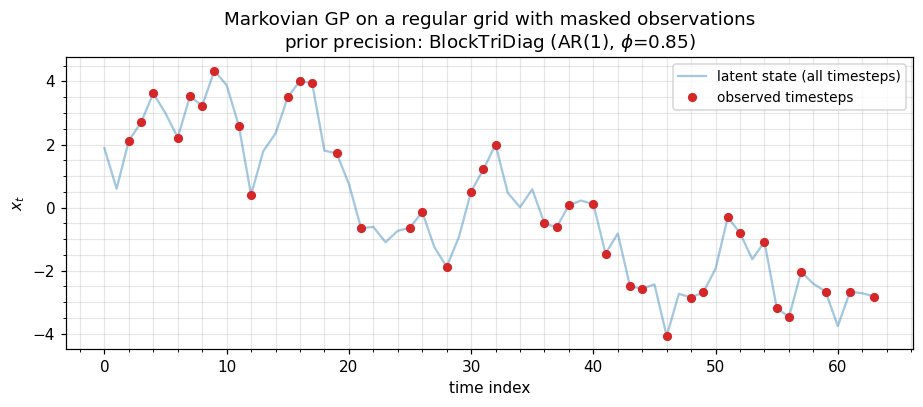

In [6]:
# AR(1)-as-state-space prior on a regular grid of N_t = 64 timesteps
N_t, d = 64, 1
phi, sigma2 = 0.85, 1.0
D_blocks = jnp.tile(((1.0 + phi**2) / sigma2) * jnp.eye(d), (N_t, 1, 1))
A_blocks = jnp.tile((-phi / sigma2) * jnp.eye(d), (N_t - 1, 1, 1))
D_blocks = D_blocks.at[0].set((1.0 / sigma2) * jnp.eye(d))
D_blocks = D_blocks.at[-1].set((1.0 / sigma2) * jnp.eye(d))
Lam = BlockTriDiag(D_blocks, A_blocks, tags=lx.positive_semidefinite_tag)

# Observation mask: 60% of timesteps observed, in clusters (geophysical-realistic)
keys = jax.random.split(jax.random.PRNGKey(60), 2)
obs_mask = jax.random.bernoulli(keys[0], p=0.6, shape=(N_t,))

# Masked Markov prior — keeps the full-grid banded prior intact, restricts I/O to observed times
M_markov = MaskedOperator(Lam, obs_mask, obs_mask, tags=lx.positive_semidefinite_tag)
print(f"full grid    : {N_t} timesteps")
print(f"observed     : {int(obs_mask.sum())} timesteps  ({100*float(obs_mask.mean()):.0f}%)")
print(f"masked shape : {M_markov.out_size()} x {M_markov.in_size()}")

# Sanity: matvec matches the explicit submatrix of the dense BTD precision
v = jax.random.normal(keys[1], (M_markov.in_size(),))
ref = Lam.as_matrix()[np.where(obs_mask)[0]][:, np.where(obs_mask)[0]] @ v
err = jnp.linalg.norm(M_markov.mv(v) - ref)
print(f"matvec error : {err:.2e}")

# Visualize: full timeline (one sample) + observation mask
L = cholesky(Lam)
z = jax.random.normal(jax.random.PRNGKey(61), (N_t * d,))
x_full = jax.scipy.linalg.solve_triangular(L.as_matrix().T, z, lower=False)
x_full = np.asarray(x_full)
t_grid = np.arange(N_t)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(t_grid, x_full, "C0-", alpha=0.4, label="latent state (all timesteps)")
ax.plot(t_grid[np.asarray(obs_mask)], x_full[np.asarray(obs_mask)], "C3o", ms=5, label="observed timesteps")
ax.set_xlabel("time index"); ax.set_ylabel("$x_t$")
ax.set_title("Markovian GP on a regular grid with masked observations\n"
             rf"prior precision: BlockTriDiag (AR(1), $\phi$={phi})")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Asymmetric masking — cross-covariance for prediction

When you want $K_{*X}$ — covariance between *test* points (rows) and *training* points (columns) — pass different masks for rows and columns:

```{math}
:label: eq:masked-cross
K_{*X} \;=\; \mathrm{MaskedOperator}(K, r=\text{test mask}, c=\text{train mask})
```

The result is rectangular and not square; matvec still costs the base operator's price. This is the cheap path for posterior-mean prediction at held-out indices.

In [7]:
# Train / test split on the 1-D Toeplitz
np.random.seed(0)
all_idx = np.arange(n)
test_idx = np.random.choice(n, size=6, replace=False)
train_mask = jnp.array([i not in test_idx for i in all_idx])
test_mask  = jnp.array([i in test_idx for i in all_idx])
print(f"train : {int(train_mask.sum())} points")
print(f"test  : {int(test_mask.sum())} points")

K_starX = MaskedOperator(T, test_mask, train_mask)  # (test x train), no PSD tag (rectangular)

# Verify
ref_starX = T.as_matrix()[np.where(test_mask)[0]][:, np.where(train_mask)[0]]
v_train = jax.random.normal(jax.random.PRNGKey(30), (K_starX.in_size(),))
err = jnp.linalg.norm(K_starX.mv(v_train) - ref_starX @ v_train)
print(f"K_*X shape        : {K_starX.out_size()} x {K_starX.in_size()}")
print(f"K_*X matvec error : {err:.2e}")

train : 18 points
test  : 6 points


K_*X shape        : 6 x 18
K_*X matvec error : 2.00e-15


## 8. What masking does to the matrix — visualization gallery

The previous sections showed *data* under masking; this one shows the *matrix*. Each row pairs the full-grid base covariance (or precision) on the left with the masked sub-matrix on the right, so the action of the mask becomes legible:

- **Plain MVN**: a generic dense Σ, with the masked rows/columns simply dropped.
- **Toeplitz**: stationary kernel on a regular grid; masking destroys the constant-diagonal property, but the entries that survive are still pulled from the same kernel function.
- **BlockTriDiag (Markovian GP)**: banded precision; masked rows/columns punch holes through the bands.
- **Asymmetric / cross-covariance** ($K_{*X}$): rectangular, train rows × test columns — the predictive-mean primitive.

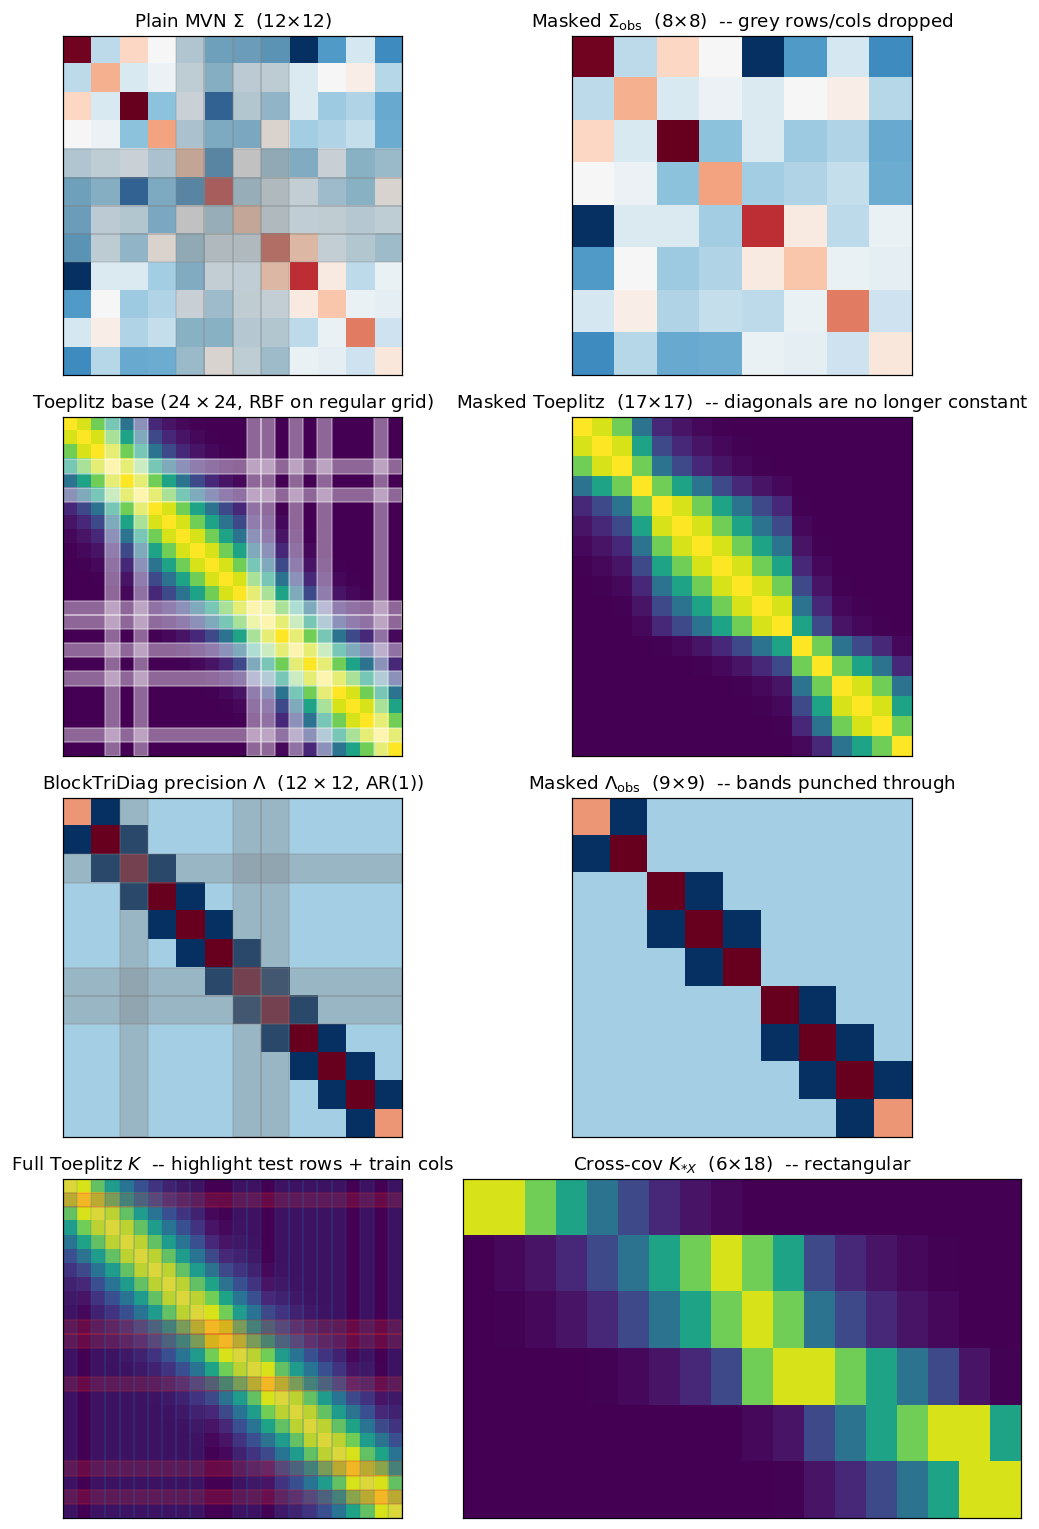

In [8]:
# Renumber the §-numbering inside the notebook is purely cosmetic — the existing
# operators (Sigma, T, Lam) are still in scope from the previous cells.
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

# ----- Row 1: plain MVN base vs masked -----
mask_mvn = jnp.array([True]*4 + [False]*4 + [True]*4)
M_mvn = MaskedOperator(Sigma_op, mask_mvn, mask_mvn, tags=lx.positive_semidefinite_tag)
vmin, vmax = float(Sigma.min()), float(Sigma.max())
axes[0,0].imshow(Sigma, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[0,0].set_title(rf"Plain MVN $\Sigma$  ({n_mvn}$\times${n_mvn})")
for k in jnp.where(~mask_mvn)[0]:
    axes[0,0].axhspan(int(k)-0.5, int(k)+0.5, color="grey", alpha=0.25)
    axes[0,0].axvspan(int(k)-0.5, int(k)+0.5, color="grey", alpha=0.25)
axes[0,1].imshow(M_mvn.as_matrix(), cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[0,1].set_title(rf"Masked $\Sigma_{{\rm obs}}$  ({M_mvn.out_size()}$\times${M_mvn.in_size()})  -- grey rows/cols dropped")

# ----- Row 2: Toeplitz base vs masked -----
T_dense = T.as_matrix()
mask_t = mask  # the §4 1-D mask, on the n=24 Toeplitz grid
M_t = MaskedOperator(T, mask_t, mask_t, tags=lx.positive_semidefinite_tag)
vmin_t, vmax_t = float(T_dense.min()), float(T_dense.max())
axes[1,0].imshow(T_dense, cmap="viridis", vmin=vmin_t, vmax=vmax_t)
axes[1,0].set_title(rf"Toeplitz base ($24\times 24$, RBF on regular grid)")
for k in jnp.where(~mask_t)[0]:
    axes[1,0].axhspan(int(k)-0.5, int(k)+0.5, color="white", alpha=0.4)
    axes[1,0].axvspan(int(k)-0.5, int(k)+0.5, color="white", alpha=0.4)
axes[1,1].imshow(M_t.as_matrix(), cmap="viridis", vmin=vmin_t, vmax=vmax_t)
axes[1,1].set_title(rf"Masked Toeplitz  ({M_t.out_size()}$\times${M_t.in_size()})  -- diagonals are no longer constant")

# ----- Row 3: Block-tridiagonal precision base vs masked -----
Lam_small_N, Lam_small_d = 12, 1
phi_s, sig2_s = 0.85, 1.0
D_s = jnp.tile(((1.0 + phi_s**2) / sig2_s) * jnp.eye(Lam_small_d), (Lam_small_N, 1, 1))
A_s = jnp.tile((-phi_s / sig2_s) * jnp.eye(Lam_small_d), (Lam_small_N - 1, 1, 1))
D_s = D_s.at[0].set((1.0 / sig2_s) * jnp.eye(Lam_small_d))
D_s = D_s.at[-1].set((1.0 / sig2_s) * jnp.eye(Lam_small_d))
Lam_s = BlockTriDiag(D_s, A_s, tags=lx.positive_semidefinite_tag)
mask_btd = jnp.array([True, True, False, True, True, True, False, False, True, True, True, True])
M_btd = MaskedOperator(Lam_s, mask_btd, mask_btd, tags=lx.positive_semidefinite_tag)
Lam_dense = Lam_s.as_matrix()
vmin_b, vmax_b = float(Lam_dense.min()), float(Lam_dense.max())
axes[2,0].imshow(Lam_dense, cmap="RdBu_r", vmin=vmin_b, vmax=vmax_b)
axes[2,0].set_title(r"BlockTriDiag precision $\Lambda$  ($12\times 12$, AR(1))")
for k in jnp.where(~mask_btd)[0]:
    axes[2,0].axhspan(int(k)-0.5, int(k)+0.5, color="grey", alpha=0.3)
    axes[2,0].axvspan(int(k)-0.5, int(k)+0.5, color="grey", alpha=0.3)
axes[2,1].imshow(M_btd.as_matrix(), cmap="RdBu_r", vmin=vmin_b, vmax=vmax_b)
axes[2,1].set_title(rf"Masked $\Lambda_{{\rm obs}}$  ({M_btd.out_size()}$\times${M_btd.in_size()})  -- bands punched through")

# ----- Row 4: Asymmetric / cross-covariance -----
# Reuse the §7 train/test split on the n=24 Toeplitz grid
axes[3,0].imshow(T_dense, cmap="viridis", vmin=vmin_t, vmax=vmax_t)
axes[3,0].set_title(r"Full Toeplitz $K$  -- highlight test rows + train cols")
for k in jnp.where(test_mask)[0]:
    axes[3,0].axhspan(int(k)-0.5, int(k)+0.5, color="C3", alpha=0.25)
for k in jnp.where(train_mask)[0]:
    axes[3,0].axvspan(int(k)-0.5, int(k)+0.5, color="C0", alpha=0.15)
axes[3,1].imshow(K_starX.as_matrix(), cmap="viridis", vmin=vmin_t, vmax=vmax_t, aspect="auto")
axes[3,1].set_title(rf"Cross-cov $K_{{*X}}$  ({K_starX.out_size()}$\times${K_starX.in_size()})  -- rectangular")

for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## 8. Solve and logdet — the catch

Masking *destroys* the structural identities that gave us cheap solve and logdet:

- A masked Toeplitz is no longer Toeplitz (the masked rows/columns break the constant-diagonal property).
- A masked Kronecker is no longer a Kronecker (the masked grid no longer factors as a tensor product).
- A masked block-tridiagonal *is* still banded, with reshuffled bandwidth — sometimes useful, often not.

So `solve(MaskedOperator(...))` and `logdet(MaskedOperator(...))` typically fall back to either:

1. **Dense materialization** ($\tilde A$) followed by Cholesky — $O(M^3)$ where $M$ is the observed count. Fine when $M$ is small.
2. **Iterative Krylov** (CG, MINRES, LSMR) using the *structured matvec* of the masked operator — $O(\text{iter} \cdot \text{base-mv-cost})$ per outer step. Fine when the base structure is preserved.

The right choice depends on the regime: **mild missingness $M \approx N$ ⇒ iterative**, **heavy missingness $M \ll N$ ⇒ dense subset**. The crossover for Toeplitz is roughly $M \sim N/\log N$.

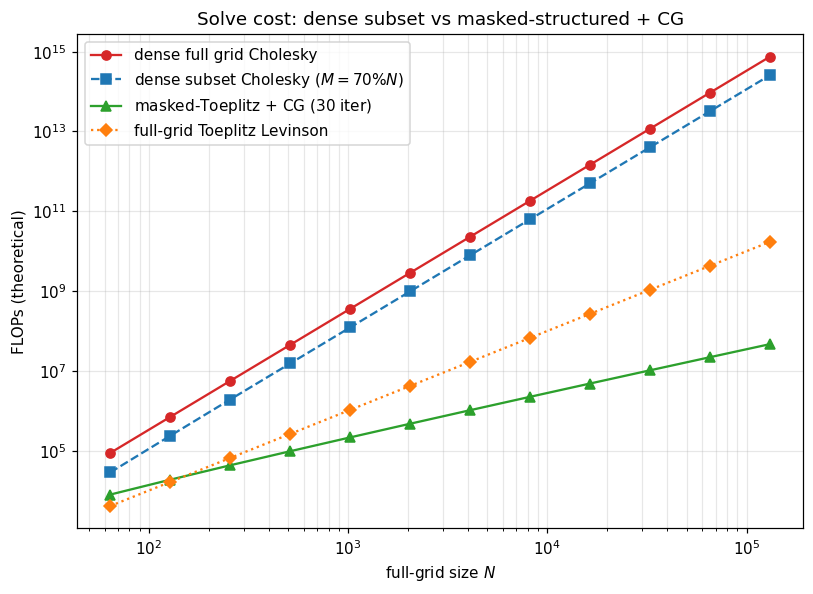

In [9]:
# Cost-table comparison (theoretical)
Ns = np.array([2**k for k in range(6, 18)])  # 64 .. 130k
M_frac = 0.7  # 30% missing
Ms = (M_frac * Ns).astype(int)

dense_full       = Ns**3 / 3
dense_subset     = Ms**3 / 3
masked_toeplitz_cg = 30 * Ms * np.log2(Ns)        # ~30 CG iterations × O(N log N) matvec
toeplitz_full_solve = Ns**2                       # Levinson-Durbin reference

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.loglog(Ns, dense_full,           "C3-",  marker="o", label=r"dense full grid Cholesky")
ax.loglog(Ns, dense_subset,         "C0--", marker="s", label=rf"dense subset Cholesky ($M={int(M_frac*100)}\%N$)")
ax.loglog(Ns, masked_toeplitz_cg,   "C2-",  marker="^", label=r"masked-Toeplitz + CG ($30$ iter)")
ax.loglog(Ns, toeplitz_full_solve,  "C1:",  marker="D", label=r"full-grid Toeplitz Levinson")
ax.set_xlabel("full-grid size $N$")
ax.set_ylabel("FLOPs (theoretical)")
ax.set_title("Solve cost: dense subset vs masked-structured + CG")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 9. Summary — when to reach for `MaskedOperator`

A short cheat-sheet:

| Scenario | Pattern |
|---|---|
| Subset of a generic MVN (CV folds, leave-one-out) | `MaskedOperator(MatrixLinearOperator(Σ), mask, mask)` |
| Markovian / state-space GP, missing timesteps (GPS, tide gauge, eddy-cov) | `MaskedOperator(BlockTriDiag, mask, mask)` |
| Stationary 1-D series, missing observations | `MaskedOperator(Toeplitz(c), mask, mask)` |
| 2-D gridded field, cloud / valid mask | `MaskedOperator(Kronecker(T_x, T_y), m, m)` |
| Train→test cross-covariance | `MaskedOperator(K, test_mask, train_mask)` (asymmetric) |
| Heavy missingness ($M \ll N$) | materialize $\tilde A$ once, dense solve |
| Mild missingness ($M \sim N$) | masked-structured matvec inside CG / MINRES |

Three notes:

- `MaskedOperator` only carries PSD / symmetric tags **when you pass them explicitly** and *only* in the symmetric-masking case. Asymmetric masks produce rectangular operators and shouldn't carry these tags.
- For irregular timestamps with no underlying regular grid, `MaskedOperator` doesn't apply — you fall back to dense covariance or inducing-point approximations (Part 5).
- Combining with `BlockTriDiag` is what powers missing-data Kalman smoothing — masked observations + Markov prior, with all primitives staying $O(N)$. We'll revisit this pattern in Part 7 (state-space GPs).

The next notebook (1.7) wraps Part 1.A by explaining the **structural-tag system** that makes all of these dispatch decisions automatic — when `gaussx.solve` sees a `BlockTriDiag` tag, it routes to the banded sweep; when it sees a `MaskedOperator` wrapping a `Kronecker`, it knows to look at the base. Tags are how the operator catalog turns into a working dispatch system.